# FSSK Signature Kernel -- Validation

## 1. Convergence validation

Validates `tensordev.kernel.fssk.fssk_sigkernel` against four reference /
alternative methods on two independent batches of n_paths 3-D unit-speed
paths (batchwise: k(X_i, Y_i)).

| Method           | Parameter swept    | Notes                              |
|------------------|--------------------|------------------------------------|  
| VSig inner prod. | truncation level N | exact SSS recursion                |
| Naive Euler      | dyadic order p     | first-order forward-Euler PDE      |
| ETD1             | dyadic order p     | exponential time-differencing, 1st |
| Heun             | dyadic order p     | predictor-corrector, 2nd order     |

Reference: VSig inner product at trunc = max_trunc (most accurate, fast).

Regimes (set REGIME in the Configuration cell below):

| Regime | max_dyadic | max_trunc | description         |
|--------|------------|-----------|---------------------|
| SMALL  | 3          | 8         | fast dev run        |
| MEDIUM | 5          | 12        | standard validation |
| LARGE  | 6          | 14        | full sweep          |

Configurations run cheapest-first.  Partial results checkpointed to
`kernel_conv_sweep_partial.pkl` after every row -- safe to interrupt.

Scripts:
  validation/sweep_kernel_convergence.py
  validation/analyse_kernel_convergence.py

In [17]:
import os, subprocess, sys
from pathlib import Path

VALIDATION_DIR = Path("validation").resolve()
OUTPUT_DIR     = VALIDATION_DIR / "validation_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _stream(cmd: list[str]) -> int:
    """Run cmd, streaming output line-by-line. Returns exit code."""
    env = {**os.environ, "PYTHONUNBUFFERED": "1"}
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True, bufsize=1, env=env,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    return proc.returncode

### 1.1 Configuration

In [22]:
# ---- Sweep regime -------------------------------------------------------
REGIME     = "SMALL"    # SMALL | MEDIUM | LARGE
N_PATHS    = 20         # paths per batch (X and Y drawn independently)

# ---- Kernel parameters (forwarded to random_fssk in fssk_setup.py) ------
KERNEL_R              = 4      # state-space dimension
KERNEL_Q              = 2      # number of FSSK components
KERNEL_M              = 3      # latent-path dimension (A: q x m x d)
KERNEL_EIG_MIN        = 0.1    # min real part (decay) of eigenvalues
KERNEL_EIG_MAX        = 1.0    # max real part (decay) of eigenvalues
KERNEL_FREQ_MIN       = 0.25    # min imaginary part (frequency) of oscillatory eigenvalues
KERNEL_FREQ_MAX       = 0.75    # max imaginary part (frequency) of oscillatory eigenvalues
KERNEL_MIN_BLOCK_SIZE = 1      # minimum Jordan chain order
KERNEL_MAX_BLOCK_SIZE = 4      # maximum Jordan chain order
KERNEL_SEED           = 42     # RNG seed for kernel parameters

# ---- Path seeds ---------------------------------------------------------
SEED_X = 20260514    # RNG seed for X batch
SEED_Y = 20260515    # RNG seed for Y batch (independent of X)

### 1.2 Run sweep

Output is streamed live -- timestamps and ETA appear after every completed row.

In [23]:
rc = _stream([
    sys.executable,
    str(VALIDATION_DIR / "sweep_kernel_convergence.py"),
    "--regime",         REGIME,
    "--n-paths",        str(N_PATHS),
    "--R",              str(KERNEL_R),
    "--q",              str(KERNEL_Q),
    "--m",              str(KERNEL_M),
    "--eig-min",        str(KERNEL_EIG_MIN),
    "--eig-max",        str(KERNEL_EIG_MAX),
    "--freq-min",       str(KERNEL_FREQ_MIN),
    "--freq-max",       str(KERNEL_FREQ_MAX),
    "--min-block-size", str(KERNEL_MIN_BLOCK_SIZE),
    "--max-block-size", str(KERNEL_MAX_BLOCK_SIZE),
    "--seed-kernel",    str(KERNEL_SEED),
    "--seed-x",         str(SEED_X),
    "--seed-y",         str(SEED_Y),
    "--output-dir",     str(OUTPUT_DIR),
])
if rc != 0:
    print(f"\n[ERROR] sweep exited with code {rc}")

[09:05:30] ══════════════════════════════════════════════════════════════════════
[09:05:30] FSSK kernel convergence sweep  —  regime SMALL  (fast dev run — p=0..3, N=1..10)
[09:05:30]   n_paths=20  J=65  d=3  dt=0.015625
[09:05:30]   max_trunc=10  max_dyadic=4  (reference: vsig_trunc N=10)
[09:05:30]   R=4  q=2  m=3  eig=[0.1, 1.0]  freq=[0.25, 0.75]  seed_kernel=42
[09:05:30]   seed_x=20260514  seed_y=20260515
[09:05:30]   output_dir=/Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/kernel/validation/validation_outputs
[09:05:30] ══════════════════════════════════════════════════════════════════════
[09:05:30] Generating path batches …
[09:05:30]   X.shape=(20, 65, 3)  Y.shape=(20, 65, 3)   (batchwise: k(X_i, Y_i))
[09:05:30] Kernel: R=4  q=2  m=3  seed=42  A.shape=(2, 3, 3)  b.shape=(2, 4)
[09:05:30] Plan: 25 configurations  (ordered cheapest-first)
[09:05:30] 
[09:05:30]   level=0  naive_euler   dyadic_order=0
[09:05:30]   level=0  etd1          dyadic_order=0
[09:05:30]

### 1.3 Analyse results

Can also be run on the partial checkpoint while the sweep is still running.

In [27]:
for out_form in ["pdf", "png"]:
    rc = _stream([
        sys.executable,
        str(VALIDATION_DIR / "analyse_kernel_convergence.py"),
        "--output-dir", str(OUTPUT_DIR),
        "--formats", out_form,
    ])
    if rc != 0:
        print(f"\n[ERROR] analyse exited with code {rc}")

/Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/kernel/validation/analyse_kernel_convergence.py:218: SyntaxWarning: invalid escape sequence '\l'
  ax_t.set_xlabel("Parameter value  (trunc $N$ / dyadic order $\lambda$)")
── Experiment metadata ─────────────────────────────────────────────────
  regime = SMALL
  n_paths = 20
  J = 65
  d = 3
  q = 2
  R = 4
  m = 3
  eig_min = 0.1
  eig_max = 1.0
  dt = 0.015625
  ref_method = vsig_trunc
  ref_trunc = 10
  seed_kernel = 42
  seed_x = 20260514
  seed_y = 20260515

── Error summary (ordered by workload level) ───────────────────────────
 workload_level      method   param_type  param_value  max_abs_error  mean_abs_error  wall_hot_s
              0        etd1 dyadic_order            0   1.805758e-04    9.586145e-05    0.076275
              0        heun dyadic_order            0   1.190827e-06    2.700215e-07    0.206055
              0 naive_euler dyadic_order            0   1.453074e-03    2.387731e-04    0.019185
         

### 1.4 Display figures


-- kernel_conv_pde --


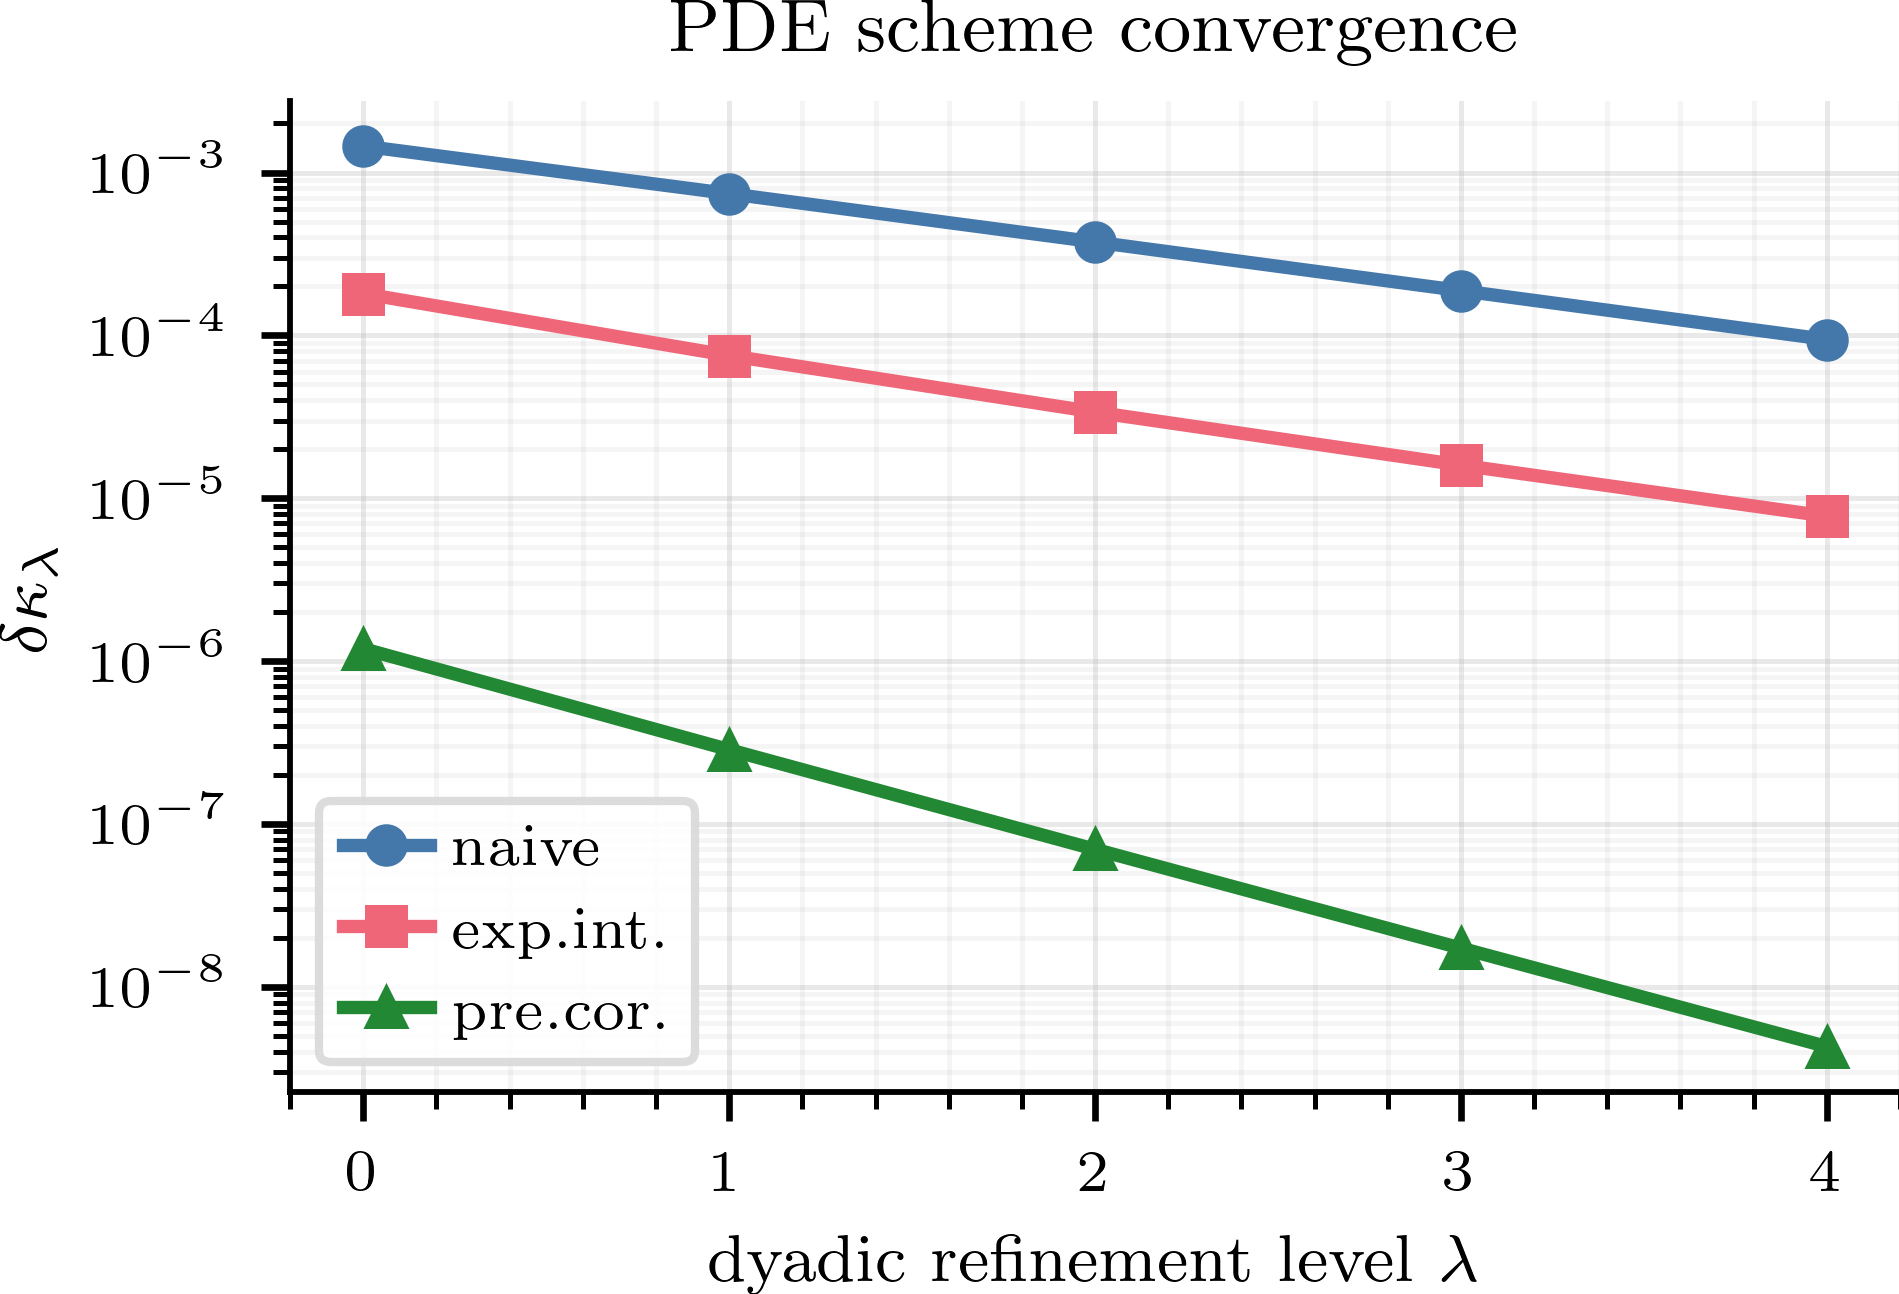

In [25]:
from IPython.display import Image, display

for stem in ["kernel_conv_pde"]:
    p = OUTPUT_DIR / f"{stem}.png"
    if p.exists():
        print(f"\n-- {stem} --")
        display(Image(str(p)))

## 2. FLOP count

Profiles `fssk_sigkernel` (ETD1 and Heun schemes) with abstract inputs
(no actual arrays allocated) to measure XLA compile-time FLOP estimates.

Random Jordan-form FSSKs are sampled from a filtered design grid.
Expected workload: **J^2 × R × (sum of Jordan block sizes^2)**.

Regimes (same as section 1):

| Regime | J range  | R range | dyadic range | samples |
|--------|----------|---------|--------------|---------|  
| SMALL  | 16..128  | 2..8    | 0..4         | 100     |
| MEDIUM | 16..256  | 2..12   | 0..5         | 300     |
| LARGE  | 16..512  | 2..16   | 0..6         | 600     |

Scripts:
  validation/sweep_kernel_flop.py
  validation/analyse_kernel_flop.py

### 2.1 Configuration

In [8]:
# Use the same REGIME variable from section 1
FLOP_REGIME = "MEDIUM"  # SMALL | MEDIUM | LARGE

### 2.2 Run FLOP sweep

Compile-only (no hot calls). Output shows progress through the design grid.

### 2.3 Analyse FLOP results

In [12]:
rc = _stream([
    sys.executable,
    str(VALIDATION_DIR / "analyse_kernel_flop.py"),
    "--output-dir", str(OUTPUT_DIR),
    "--formats", "png",
])
if rc != 0:
    print(f"\n[ERROR] FLOP analyse exited with code {rc}")

Auto-detected input: kernel_flop_scaling_medium.pkl
── Experiment metadata ─────────────────────────────────────────────────
  regime = MEDIUM
  n_paths = 2
  d = 3
  q = 1
  m = 3
  jordan_form = True

── Summary ─────────────────────────────────────────────────────────────
  Total configs: 500
  Schemes: ['heun']
  J range: 257..815
  R range: 6..13
  dyadic range: 0..0

── Fitted cost model ───────────────────────────────────────────────────
  heun:  log(FLOPs) = 5.69 + 2.01·log(J_eff) + 2.04·log(R) + -0.00·log(q)
           R² = 0.9992  (expect c_q ≈ 2, c_J ≈ 2, c_R ≈ 2)

Saved:
  /Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/kernel/validation/validation_outputs/kernel_flop_summary.csv
  /Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/kernel/validation/validation_outputs/kernel_flop_fit.csv

── Precomp vs PDE-solver cost breakdown (Heun) ─────────────────────────
  rows with valid precomp+pde data : 500
  precomp fraction  mean=1.000  median=1.000  min=0

### 2.4 Display FLOP figures


-- kernel_flop_scaling --


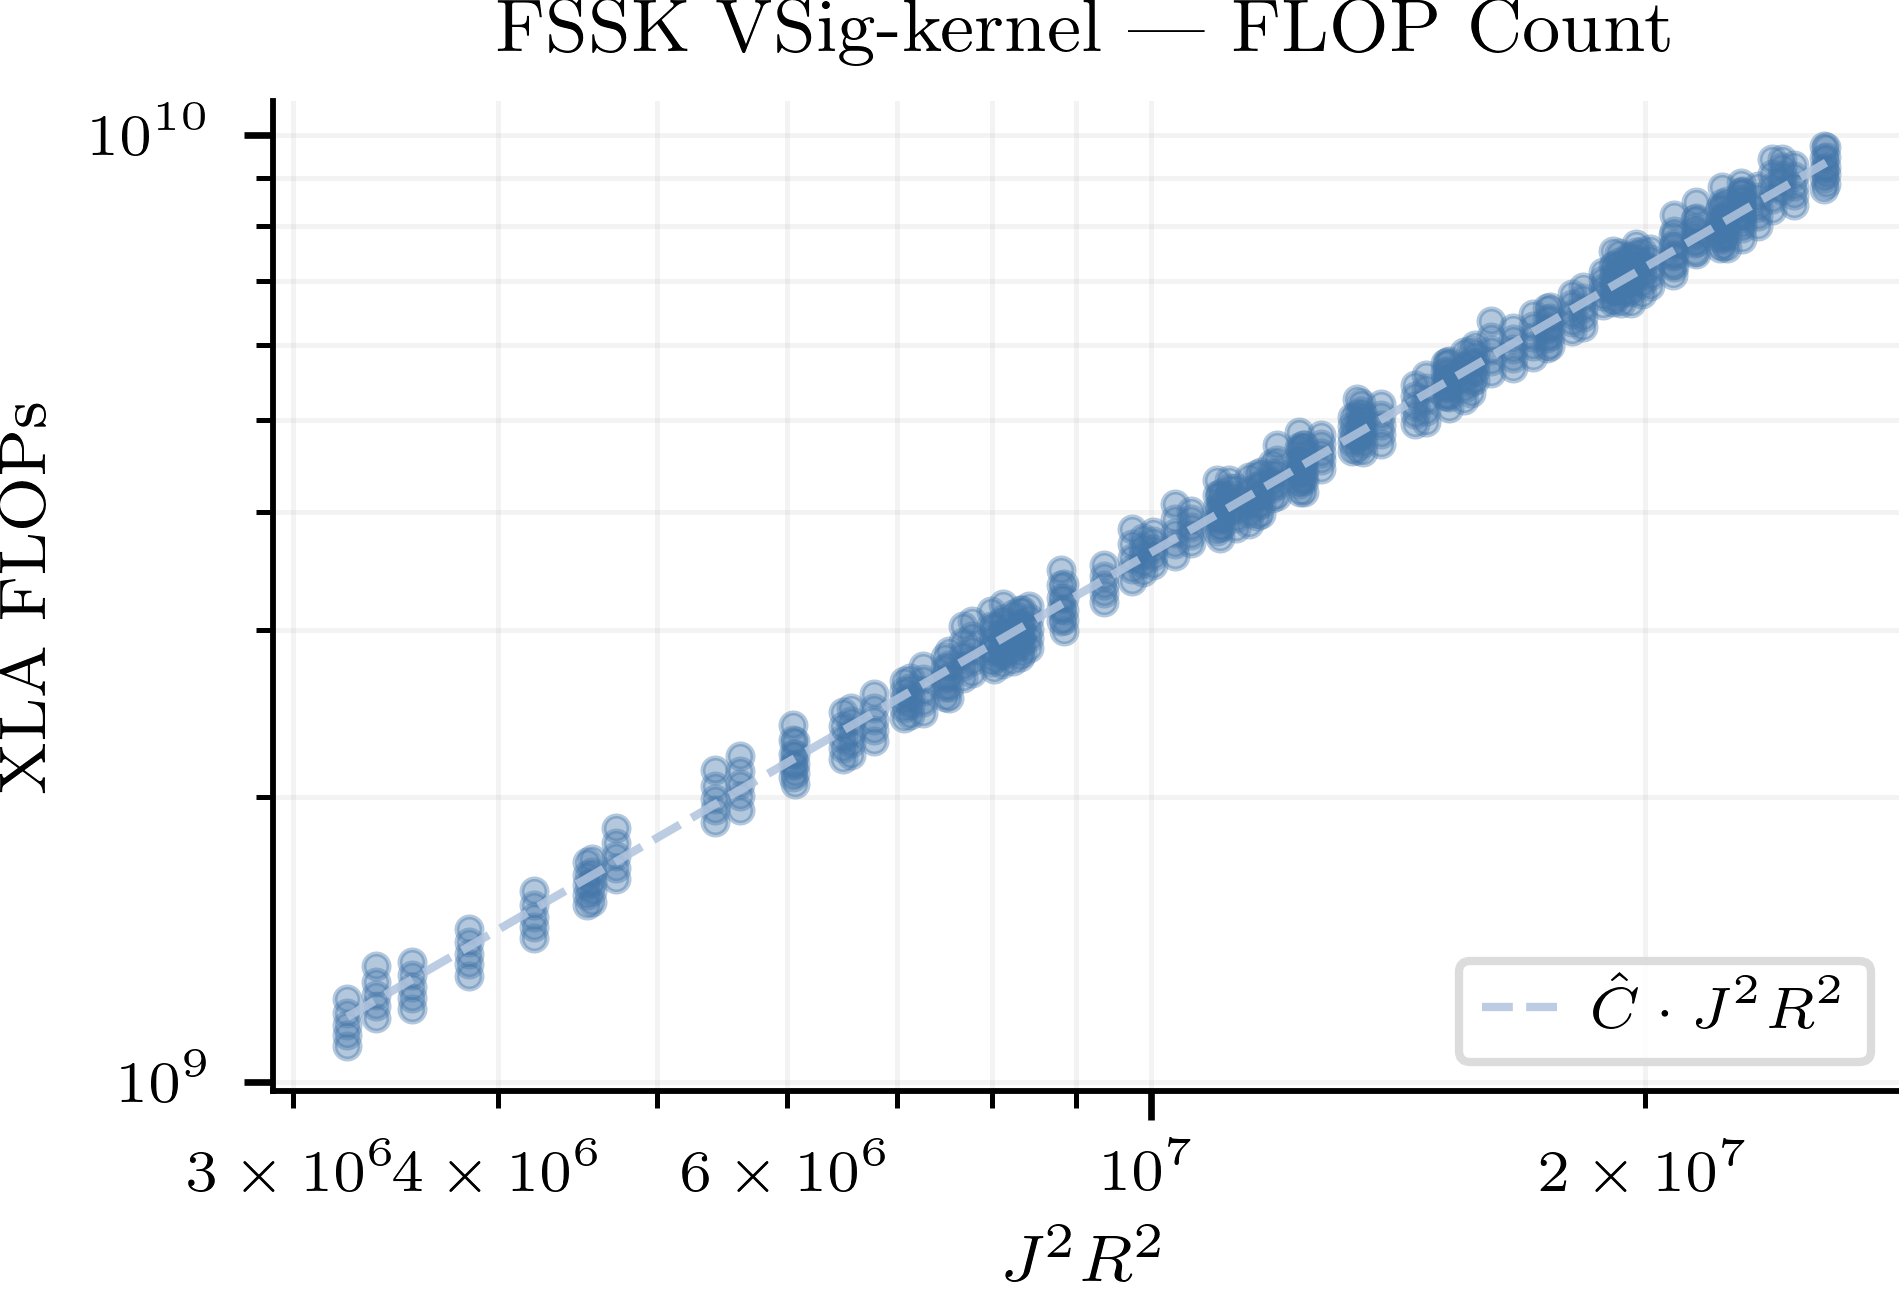

In [13]:
from IPython.display import Image, display

for stem in ["kernel_flop_scaling"]:
    p = OUTPUT_DIR / f"{stem}.png"
    if p.exists():
        print(f"\n-- {stem} --")
        display(Image(str(p)))